In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
# Load the cleaned dataset
listings = pd.read_csv("../data/listings_clean.csv")

# Check it loaded correctly
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_clean,has_rating
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,4.78,NaN,NaN,5,0,5,0,0.08,113.97,True
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.59,NaN,NaN,1,1,0,0,0.95,117.27,True
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,NaN,NaN,2,0,2,0,0.04,80.06,True
3,6990,https://www.airbnb.com/rooms/6990,20260614073253,2026-06-14,city scrape,UES Beautiful Blue Room,Beautiful peaceful healthy home,NaN,https://a0.muscache.com/pictures/45fb4ec7-6856...,16800,...,4.84,NaN,NaN,1,0,1,0,1.24,77.17,True
4,7097,https://www.airbnb.com/rooms/7097,20260614073253,2026-06-14,city scrape,"Perfect for Your Parents, With Garden & Patio",Parents/grandparents coming to town or are you...,NaN,https://a0.muscache.com/pictures/aaac19fc-4b4d...,17571,...,4.82,NaN,NaN,2,0,2,0,2.12,202.47,True


In [5]:
# ================================================
# Dataset overview
# ================================================

print("Shape:", listings.shape)

listings.info()

Shape: (21364, 92)
<class 'pandas.DataFrame'>
RangeIndex: 21364 entries, 0 to 21363
Data columns (total 92 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            21364 non-null  int64  
 1   listing_url                                   21364 non-null  str    
 2   scrape_id                                     21364 non-null  int64  
 3   last_scraped                                  21364 non-null  str    
 4   source                                        21364 non-null  str    
 5   name                                          21364 non-null  str    
 6   description                                   20828 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   21364 non-null  str    
 9   host_id                                       21364 n

In [6]:
# ================================================
# Summary statistics for numerical variables
# ================================================

listings.describe().round(2)

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_clean
count,2.136400e+04,2.136400e+04,0.0,2.136400e+04,2.108600e+04,0.0,21086.00,21086.00,21086.00,21086.00,...,15394.00,15393.00,15394.00,0.0,21364.00,21364.00,21364.00,21364.00,15394.00,21364.00
mean,7.315856e+17,2.026061e+13,NaN,3.785653e+15,1.471003e+18,NaN,7.66,5.63,6.02,5.60,...,4.81,4.73,4.61,NaN,31.74,22.88,7.80,0.13,1.08,271.89
std,6.159591e+17,0.000000e+00,NaN,7.977967e+16,2.738138e+16,NaN,4.02,3.49,3.90,3.38,...,0.42,0.39,0.51,NaN,78.87,73.22,31.22,1.33,2.12,504.45
min,2.539000e+03,2.026061e+13,NaN,1.678000e+03,1.462506e+18,NaN,0.00,0.00,0.00,0.00,...,1.00,1.00,1.00,NaN,1.00,0.00,0.00,0.00,0.01,4.58
25%,4.331531e+07,2.026061e+13,NaN,2.796180e+07,1.462956e+18,NaN,4.00,3.00,3.00,3.00,...,4.80,4.64,4.50,NaN,1.00,0.00,0.00,0.00,0.15,96.50
50%,8.108339e+17,2.026061e+13,NaN,1.622809e+08,1.466756e+18,NaN,8.00,6.00,5.00,5.00,...,4.94,4.83,4.75,NaN,3.00,1.00,1.00,0.00,0.40,173.36
75%,1.255824e+18,2.026061e+13,NaN,4.468202e+08,1.469866e+18,NaN,11.00,9.00,9.00,8.00,...,5.00,5.00,4.89,NaN,14.00,4.00,2.00,0.00,1.33,299.00
max,1.707075e+18,2.026061e+13,NaN,1.704453e+18,1.706707e+18,NaN,17.00,11.00,15.00,11.00,...,5.00,5.00,5.00,NaN,955.00,955.00,231.00,22.00,115.63,30972.96


In [7]:
# ================================================
# Summary statistics for key analysis variables
# ================================================

important_numeric = [
    "price_clean",
    "accommodates",
    "bedrooms",
    "beds",
    "review_scores_rating",
    "number_of_reviews",
    "availability_365"
]

listings[important_numeric].describe().round(2)

,price_clean,accommodates,bedrooms,beds,review_scores_rating,number_of_reviews,availability_365
count,21364.00,21364.00,21364.00,21364.00,21364.00,21364.00,21364.00
mean,271.89,2.93,1.04,1.58,3.40,39.43,245.68
std,504.45,2.09,1.08,1.29,2.16,90.15,105.17
min,4.58,1.00,0.00,0.00,0.00,0.00,0.00
25%,96.50,2.00,0.00,1.00,0.00,0.00,165.00
50%,173.36,2.00,1.00,1.00,4.71,6.00,272.00
75%,299.00,4.00,2.00,2.00,4.94,41.00,336.00
max,30972.96,16.00,19.00,40.00,5.00,4502.00,365.00


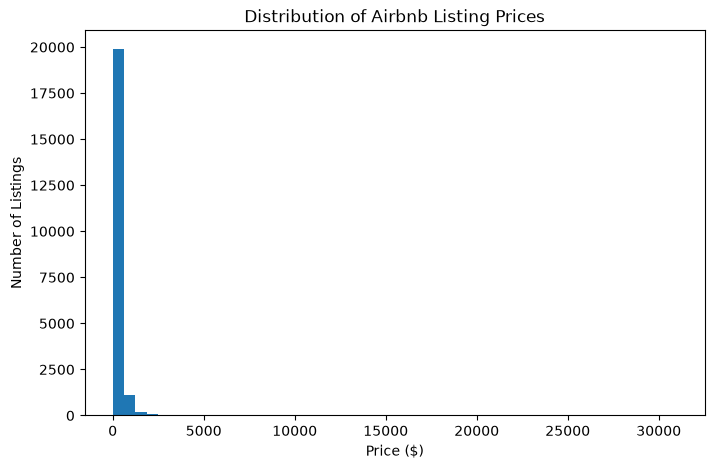

In [8]:
# ================================================
# Distribution of listing prices
# ================================================

plt.figure(figsize=(8, 5))

plt.hist(listings["price_clean"], bins=50)

plt.title("Distribution of Airbnb Listing Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

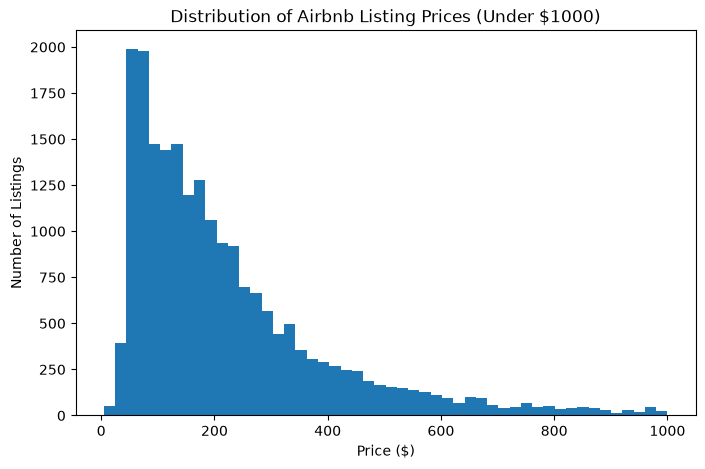

In [9]:
# ================================================
# Distribution of prices under $1000
# ================================================

plt.figure(figsize=(8, 5))

plt.hist(
    listings.loc[listings["price_clean"] <= 1000, "price_clean"],
    bins=50
)

plt.title("Distribution of Airbnb Listing Prices (Under $1000)")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

/var/folders/_3/ll1xnc_14l76_3yfx9jrl73r0000gn/T/ipykernel_8415/1814832201.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(listings["price_clean"], vert=False)


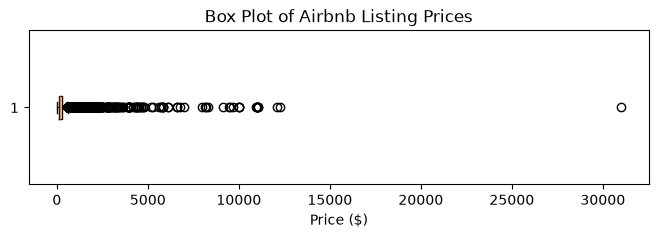

In [10]:
# ================================================
# Box plot of listing prices
# ================================================

plt.figure(figsize=(8, 2))

plt.boxplot(listings["price_clean"], vert=False)

plt.title("Box Plot of Airbnb Listing Prices")
plt.xlabel("Price ($)")

plt.show()

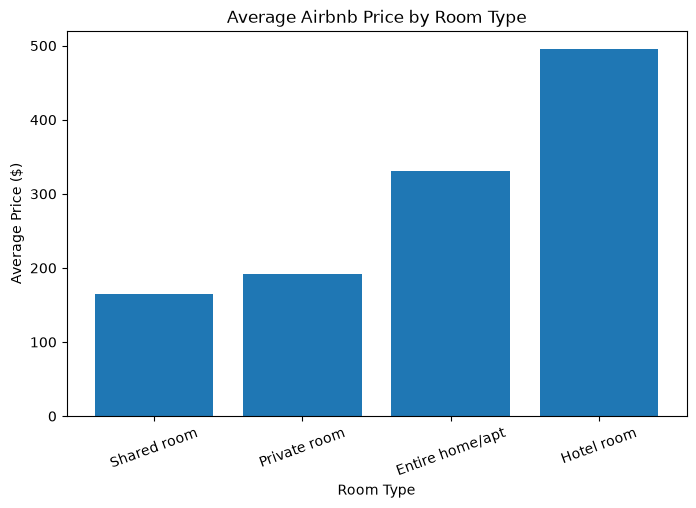

In [11]:
# ================================================
# Average price by room type
# ================================================

room_prices = (
    listings.groupby("room_type")["price_clean"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))

plt.bar(room_prices.index, room_prices.values)

plt.title("Average Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=20)

plt.show()

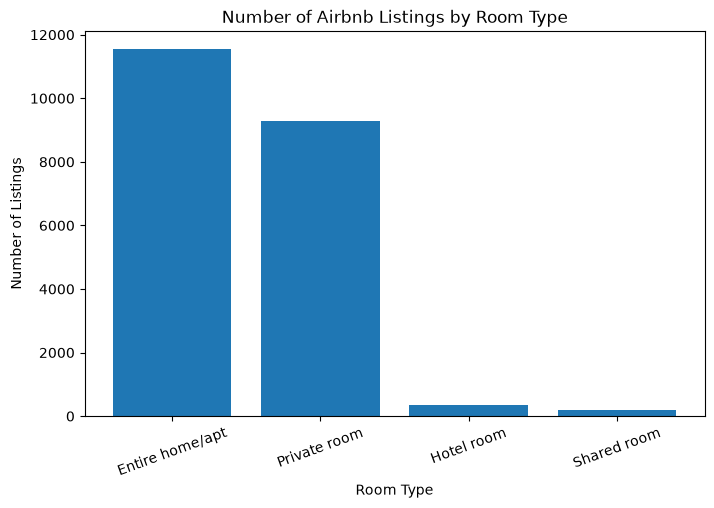

In [12]:
# ================================================
# Number of listings by room type
# ================================================

room_counts = listings["room_type"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(room_counts.index, room_counts.values)

plt.title("Number of Airbnb Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=20)

plt.show()

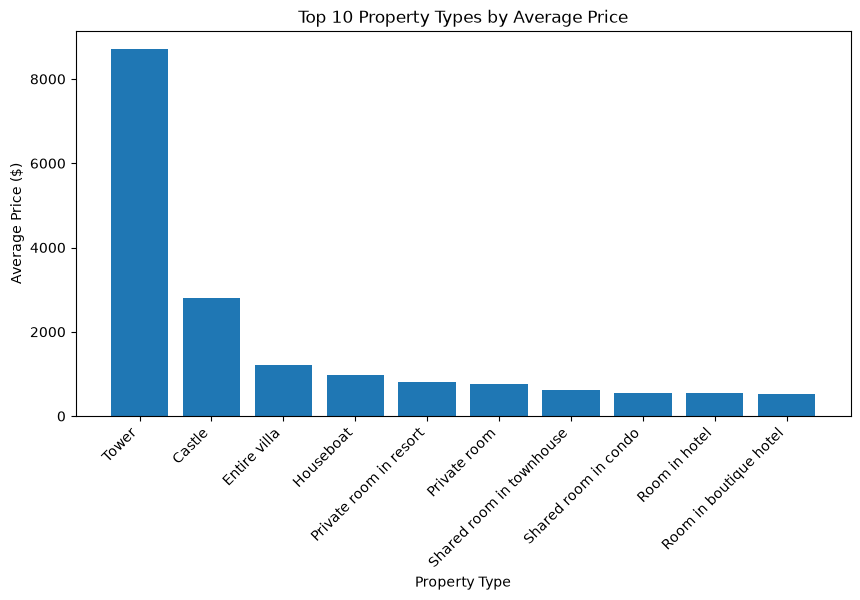

In [13]:
# ================================================
# Top 10 property types by average price
# ================================================

property_prices = (
    listings.groupby("property_type")["price_clean"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.bar(property_prices.index, property_prices.values)

plt.title("Top 10 Property Types by Average Price")
plt.xlabel("Property Type")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45, ha="right")

plt.show()

In [14]:
# ================================================
# Most common property types
# ================================================

listings["property_type"].value_counts().head(15)

property_type
Entire rental unit             8637
Private room in rental unit    4700
Private room in home           2129
Room in hotel                  1241
Entire home                    1035
Entire condo                    659
Private room in townhouse       629
Entire townhouse                332
Private room in condo           296
Entire loft                     254
Entire guest suite              234
Entire serviced apartment       178
Room in boutique hotel          173
Shared room in rental unit      140
Private room in guest suite     119
Name: count, dtype: int64

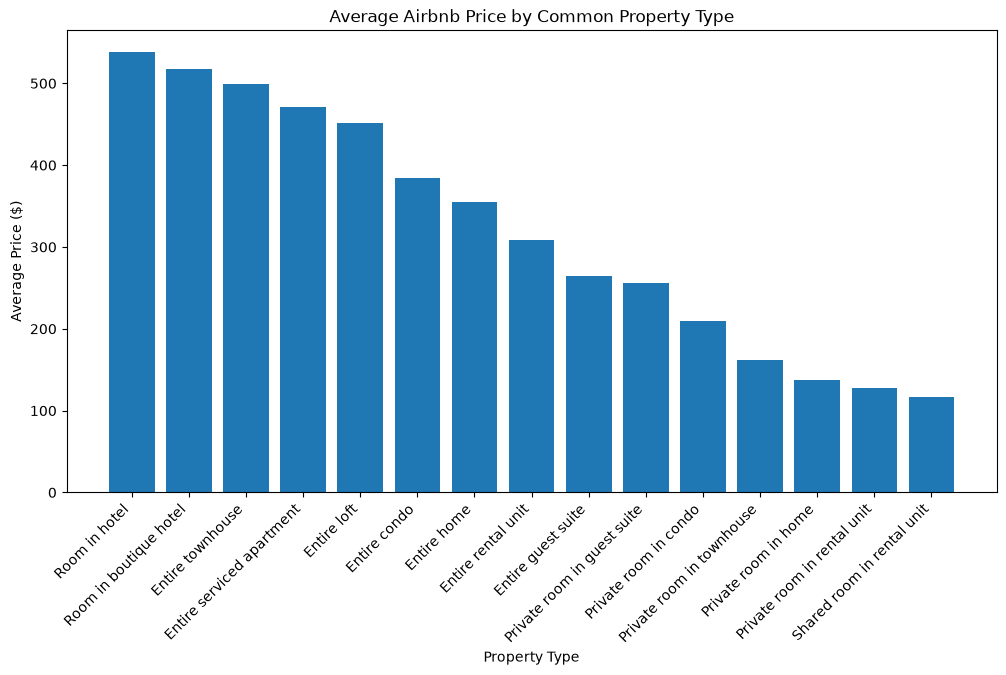

In [16]:
# ================================================
# Average price of common property types
# ================================================

# Keep only property types with at least 100 listings
common_types = listings["property_type"].value_counts()
common_types = common_types[common_types >= 100].index

avg_price = (
    listings[listings["property_type"].isin(common_types)]
    .groupby("property_type")["price_clean"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

plt.bar(avg_price.index, avg_price.values)

plt.title("Average Airbnb Price by Common Property Type")
plt.xlabel("Property Type")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45, ha="right")

plt.show()

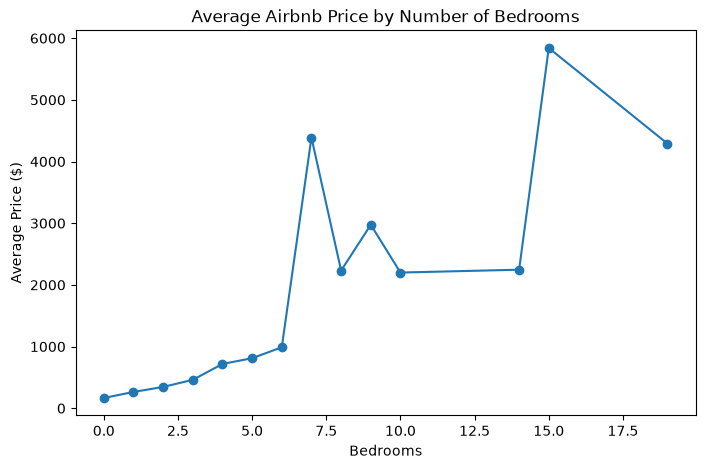

In [17]:
# ================================================
# Average price by number of bedrooms
# ================================================

bedroom_price = (
    listings.groupby("bedrooms")["price_clean"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.plot(
    bedroom_price.index,
    bedroom_price.values,
    marker="o"
)

plt.title("Average Airbnb Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")

plt.show()

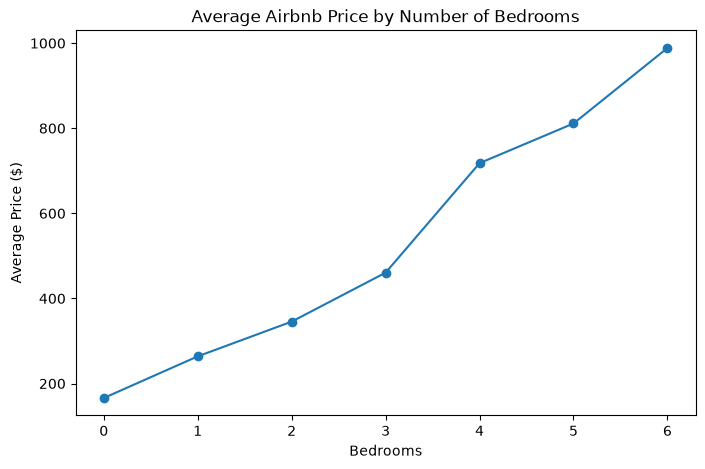

In [18]:
# ================================================
# Average price by number of bedrooms (0–6 only)
# ================================================

bedroom_price = (
    listings[listings["bedrooms"] <= 6]
    .groupby("bedrooms")["price_clean"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.plot(
    bedroom_price.index,
    bedroom_price.values,
    marker="o"
)

plt.title("Average Airbnb Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")

plt.show()

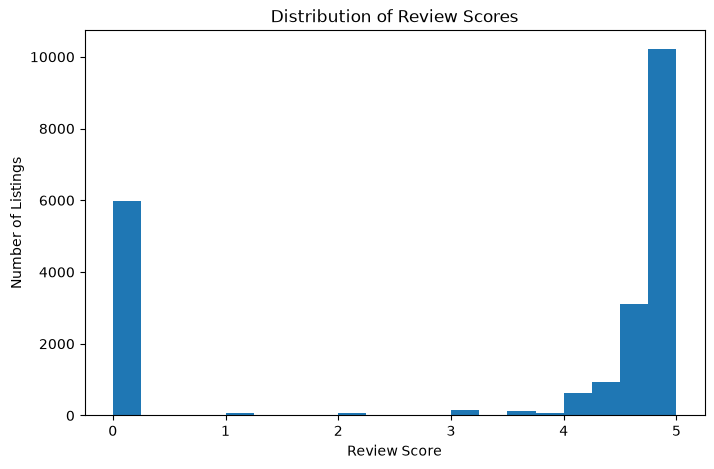

In [19]:
# ================================================
# Distribution of review scores
# ================================================

plt.figure(figsize=(8,5))

plt.hist(
    listings["review_scores_rating"],
    bins=20
)

plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Listings")

plt.show()

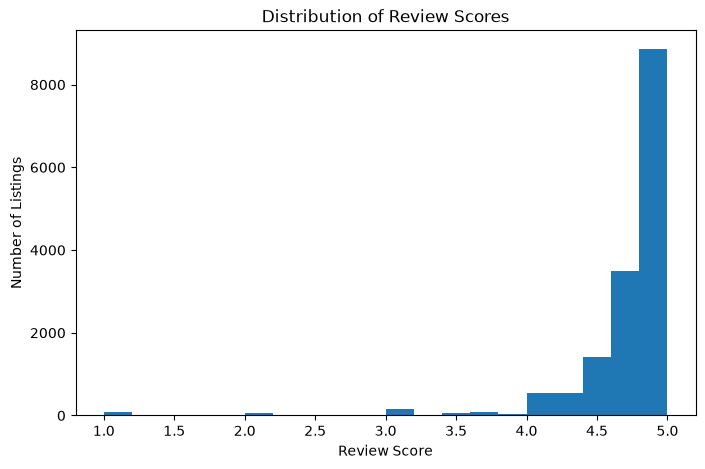

In [20]:
# ================================================
# Distribution of review scores (rated listings only)
# ================================================

ratings = listings.loc[
    listings["review_scores_rating"] > 0,
    "review_scores_rating"
]

plt.figure(figsize=(8, 5))

plt.hist(ratings, bins=20)

plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Listings")

plt.show()